<a href="https://colab.research.google.com/github/crahulnaidu/recursive-self-improving-ai/blob/main/month_1/ai_month_day_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

In [ ]:
def softmax(z):
  exp_z=np.exp(z-np.max(z))

  return exp_z/np.sum(exp_z,axis=1,keepdims=True)


In [ ]:
X=np.random.randn(100,2)
y=np.random.randint(0,3,size=(100,1))

y_one_hot=np.eye(3)[y.reshape(-1)]

X_b=np.c_[np.ones((100,1)),X]


In [ ]:
theta=np.random.randn(3,3) # 3 features,3 classes
lr=0.1

for _ in range(1000):
  z=X_b @ theta
  probs=softmax(z)

  gradients=X_b.T@(probs-y_one_hot)
  theta=theta-lr*gradients


In [ ]:
def predict(X):
  z=softmax(X @ theta)
  return np.argmax(z,axis=1)

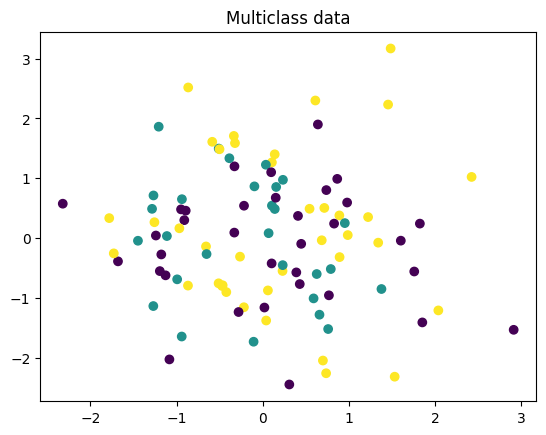

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0],X[:,1],c=y.flatten())
plt.title("Multiclass data")
plt.show()

In [1]:
#visualizing decision boundaries

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
n=150
X=np.random.randn(n,2)
y = np.zeros(n)
y[(X[:,0] + X[:,1] > 1)] = 1
y[(X[:,0] - X[:,1] > 1)] = 2

y = y.astype(int)

# One-hot encoding
y_one_hot = np.eye(3)[y]

def softmax(z):
  exp_z=np.exp(z-np.max(z))

  return exp_z/np.sum(exp_z,axis=1,keepdims=True)


#Train model

X_b=np.c_[np.ones((n,1)),X]

theta=np.random.randn(3,3)
lr=0.1

for _ in range(1000):
  z=X_b @ theta
  probs=softmax(z)
  gradients=(1/n)*X_b.T@(probs-y_one_hot)
  theta=theta-lr*gradients

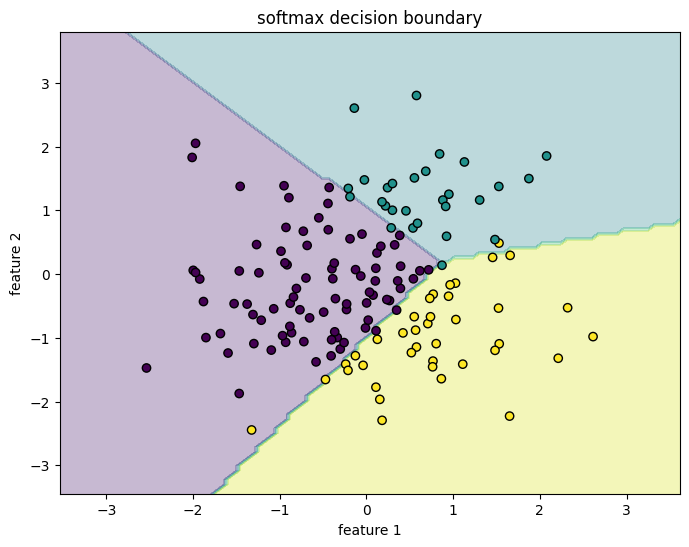

In [20]:
#create grid

x_min,x_max=X[:,0].min()-1,X[:,0].max()+1
y_min,y_max=X[:,1].min()-1,X[:,1].max()+1

xx,yy=np.meshgrid(np.linspace(x_min,x_max,100),np.linspace(y_min,y_max,100))

grid=np.c_[xx.ravel(),yy.ravel()]
grid_b=np.c_[np.ones((grid.shape[0],1)),grid]

#predict on grid

probs=softmax(grid_b @ theta)
preds=np.argmax(probs,axis=1)
preds=preds.reshape(xx.shape)

#plot decision boundary

plt.figure(figsize=(8,6))

plt.contourf(xx,yy,preds,alpha=0.3)

plt.scatter(X[:,0],X[:,1],c=y,edgecolor='k')

plt.title("softmax decision boundary")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.show()